<a href="https://colab.research.google.com/github/Rifath-Mahmud/CVPR/blob/main/Chapter07/Understanding_selectivesearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install -qq selectivesearch
%pip install -qq torch_snippets
from torch_snippets import *
import selectivesearch
from skimage.segmentation import felzenszwalb

In [12]:
!wget -q 'https://plus.unsplash.com/premium_photo-1723489241607-ddbb1de7eac1?q=80&w=870&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D' -O MyImage.jpg
img = read('MyImage.jpg', 1)

In [13]:
segments_fz = felzenszwalb(img, scale=200)

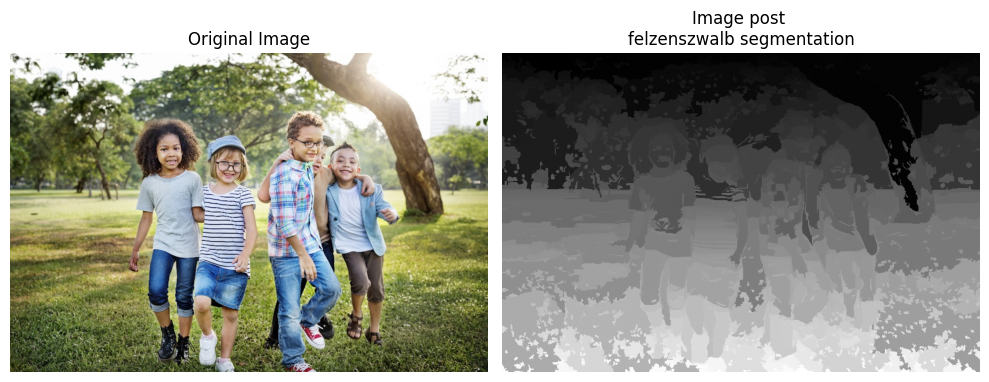

In [14]:
subplots([img, segments_fz], titles=['Original Image','Image post \nfelzenszwalb segmentation'], figsize=(10,10), nc=2)

In [23]:
def extract_candidates(img):
    img_lbl, regions = selectivesearch.selective_search(img, scale=200, min_size=100)
    img_area = np.prod(img.shape[:2])
    candidates = []
    for r in regions:
        if r['rect'] in candidates: continue
        if r['size'] < (0.05*img_area): continue
        if r['size'] > (1*img_area): continue
        x, y, w, h = r['rect']
        candidates.append(list(r['rect']))
    return candidates


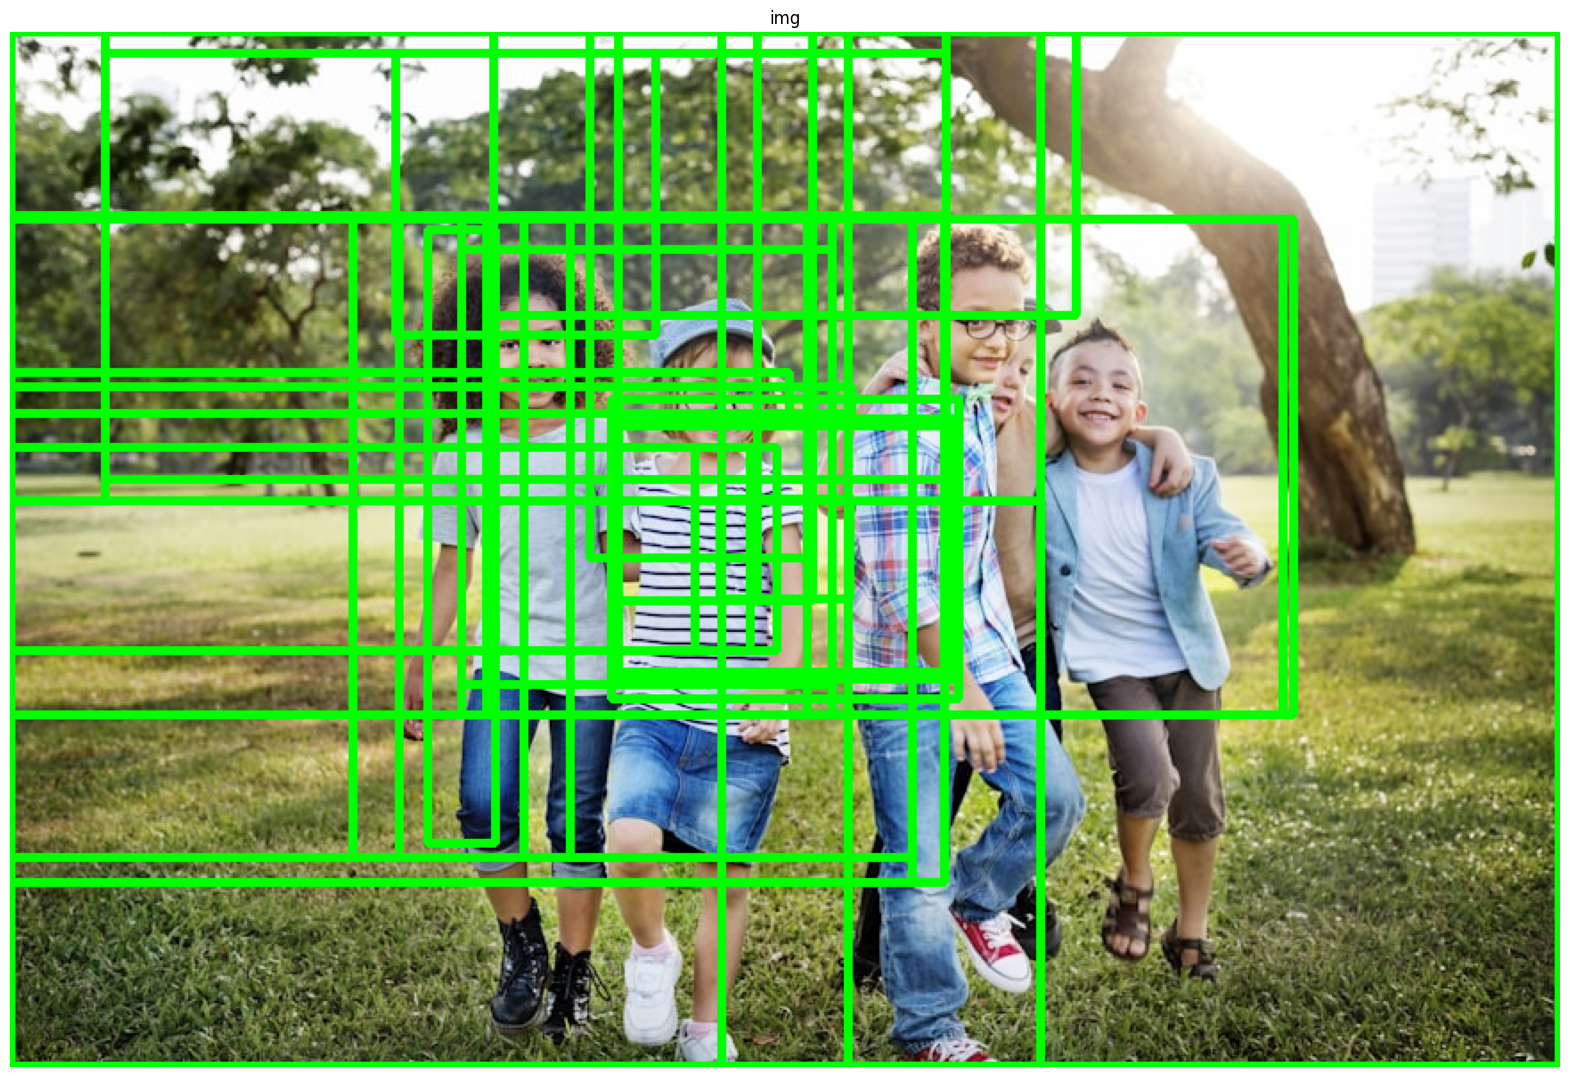

In [24]:
candidates = extract_candidates(img)
show(img, bbs = candidates)